## import and data loading
Load dataset from the raw data downloaded in ..data/raw/creditcard.csv

In [17]:

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("../data/raw/creditcard.csv")

## Data overview

In [18]:

print("Dimensions:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nFirst five rows:")
print(df.head())

print("\nDataset information:")
df.info()

print("\nSummary statistics:")
print(df.describe(include="all"))

Dimensions: (284807, 31)

Column names:
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

First five rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225

## Missing values and class distribution

In [19]:
print("Class distribution:")
print(df["Class"].value_counts())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

print("\nUnique values per column:")
print(df.nunique())

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing values:
0

Unique values per column:
Time      124592
V1        275663
V2        275663
V3        275663
V4        275663
V5        275663
V6        275663
V7        275663
V8        275663
V9        275663
V10       275663
V11       275663
V12       275663
V13       275663
V14       275663
V15       275663
V16       275663
V17       275663
V18       275663
V19       275663
V20       275663
V21       275663
V22       275663
V23       275663
V24       275663
V25       275663
V26       275663


## Feature distributions/visualizations

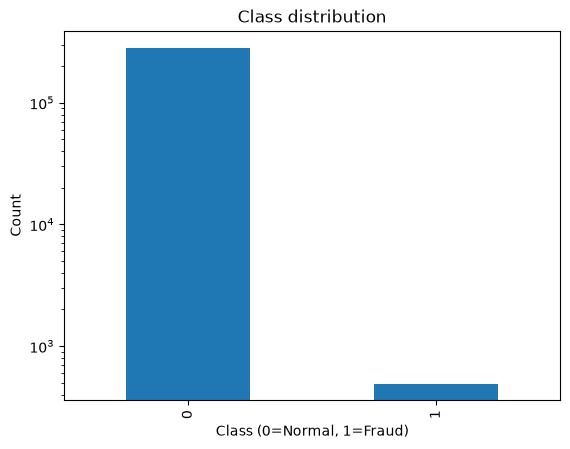

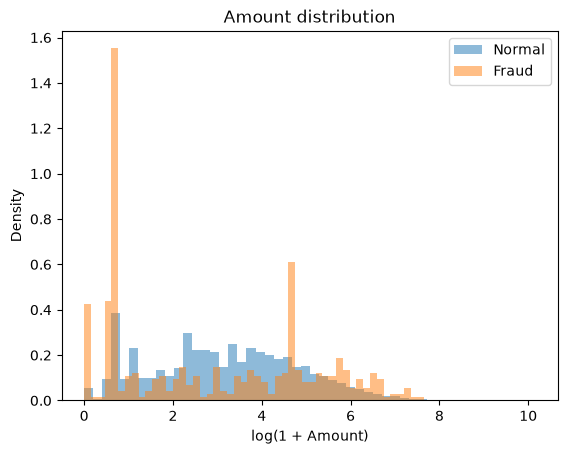

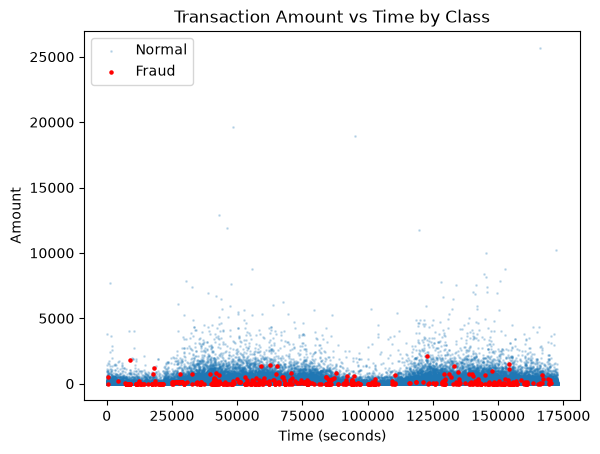

In [20]:
plt.title("Class distribution")
df["Class"].value_counts().plot(kind="bar")
plt.xlabel("Class (0=Normal, 1=Fraud)")
plt.ylabel("Count")
plt.yscale("log")  
plt.show()


plt.title("Amount distribution")
fraud = df[df["Class"] == 1]["Amount"]
normal = df[df["Class"] == 0]["Amount"]
plt.hist(np.log1p(normal), bins=50, alpha=0.5, label="Normal", density=True)
plt.hist(np.log1p(fraud), bins=50, alpha=0.5, label="Fraud", density=True)
plt.xlabel("log(1 + Amount)")
plt.ylabel("Density")
plt.legend()
plt.show()


plt.title("Transaction Amount vs Time by Class")
plt.scatter(df[df["Class"]==0]["Time"], df[df["Class"]==0]["Amount"], s=1, alpha=0.2, label="Normal")
plt.scatter(df[df["Class"]==1]["Time"], df[df["Class"]==1]["Amount"], s=5, color="red", label="Fraud")
plt.xlabel("Time (seconds)")
plt.ylabel("Amount")
plt.legend()
plt.show()


### Observations
- Plot 1: Distribution is heavily skewed (leaning towards normal transactions).
- Plot 2: 
    - Fraud transactions cluster around a few fixed amounts (sharp spikes), while normal transactions spread across a wider range of amounts.
    - Smaller amounts have higher density in fraud cases.
- Plot 3: Fraud transactions are spread evenly across the time range, not clustered at any particular time — so Time alone isn't a strong indicator of fraud.


## Correlation analysis

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


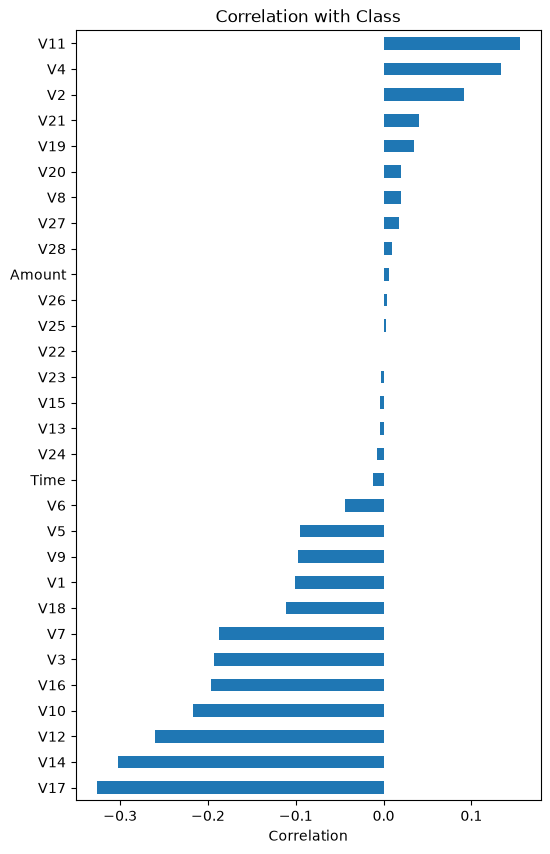

In [21]:
corr = df.corr()
print(corr["Class"].sort_values(ascending=False))

corr["Class"].drop("Class").sort_values().plot(kind="barh", figsize=(6,10))
plt.title("Correlation with Class")
plt.xlabel("Correlation")
plt.show()

### Observations
- Most PCA features show weak correlation with each other.
- Some features (V17, V14, V12) show stronger correlation with `Class`.
- `Amount` and `Time` are barely correlated to fraud.

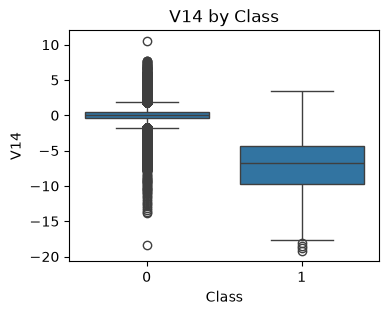

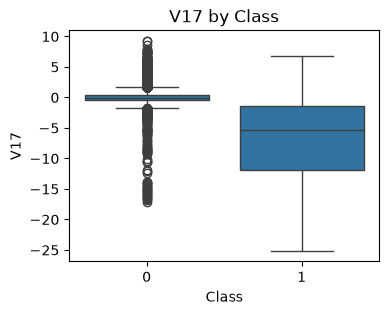

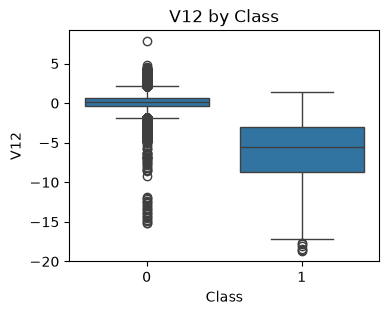

In [22]:
# fig, axes = plt.subplots(7, 4, figsize=(16, 24))
# axes = axes.flatten()

# for i in range(1, 29):
#     col = f"V{i}"
#     sns.boxplot(x="Class", y=col, data=df, ax=axes[i-1])
#     axes[i-1].set_title(col)

# plt.tight_layout()
# plt.show()

for col in ["V14", "V17", "V12"]:
    plt.figure(figsize=(4, 3))
    sns.boxplot(x="Class", y=col, data=df)
    plt.title(f"{col} by Class")
    plt.show()

### Observations
- V14, V17, and V12 show clear separation between classes, fraud transactions have noticeably lower (more negative) values than normal transactions, with minimal overlap between the two boxes.
- Normal transactions cluster tightly near 0 for these features, with a large number of outliers extending in both directions due to the much larger sample size.
- Fraud transactions show a wider spread (larger box) but consistently sit in negative territory, confirming these features as strong candidates for distinguishing fraud from normal transactions.

## Conclusions

- Fraud is extremely rare (~0.17% of transactions), so accuracy isn't a useful metric here ,and precision, recall, and AUPRC should be used instead (as Kaggle itself recommends).
- Amount and Time are weak predictors on their own. Fraud does cluster at smaller amounts, but shows no clustering across time.
- V14, V17, and V12 are the strongest individual predictors — both correlation and boxplots confirm clear separation between fraud and normal.
- Next step: handle the class imbalance (SMOTE/undersampling or class weights) and evaluate future models using precision-recall metrics, not accuracy.